# Tarea 3 IA - Redes Convolucionales (CNNs)

## 1. Preparación del Entorno y Carga de Datos

En esta sección importaremos las librerías necesarias y cargaremos el dataset de imágenes.

In [1]:
!pip install -r requirements.txt

In [2]:
import os
import zipfile

# Ruta del archivo zip y directorio de destino
zip_path = './fotos/DESCOMPRIMIR.zip'
extract_to = './fotos'
required_folders = ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Residential', 'SeaLake']

# Verificar si faltan carpetas
missing_folders = [f for f in required_folders if not os.path.exists(os.path.join(extract_to, f))]

if missing_folders:
    print(f"Faltan carpetas: {missing_folders}. Intentando descomprimir {zip_path}...")
    if os.path.exists(zip_path):
        try:
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall(extract_to)
            print("Descompresión completada exitosamente.")
        except zipfile.BadZipFile:
            print(f"Error: El archivo {zip_path} está corrupto o no es un zip válido.")
        except Exception as e:
            print(f"Error al descomprimir: {e}")
    else:
        print(f"Error: No se encontró el archivo {zip_path}. Asegúrese de que esté en la ruta correcta.")
else:
    print("Todas las carpetas de imágenes ya existen. No es necesario descomprimir.")


Faltan carpetas: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Residential', 'SeaLake']. Intentando descomprimir ./fotos/DESCOMPRIMIR.zip...
Descompresión completada exitosamente.


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import torchvision
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import accuracy_score, f1_score

# Configuración de semilla para reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

# Verificar dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


In [4]:
# Transformaciones: Redimensionar a 64x64, convertir a Tensor y Normalizar
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) # Normalizar a [-1, 1]
])

# Ruta del dataset
dataset_path = './fotos'

try:
    # Cargar dataset usando ImageFolder
    full_dataset = datasets.ImageFolder(root=dataset_path, transform=transform)
    classes = full_dataset.classes
    print(f"Clases encontradas: {classes}")
    
    # Dividir dataset (70% Train, 15% Val, 15% Test)
    total_size = len(full_dataset)
    train_size = int(0.7 * total_size)
    val_size = int(0.15 * total_size)
    test_size = total_size - train_size - val_size

    train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

    # DataLoaders
    batch_size = 32
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    print(f"Tamaño Entrenamiento: {len(train_dataset)}")
    print(f"Tamaño Validación: {len(val_dataset)}")
    print(f"Tamaño Prueba: {len(test_dataset)}")
    
except Exception as e:
    print(f"Error al cargar el dataset: {e}")
    print("Asegúrese de que la carpeta './fotos' exista y contenga las subcarpetas de clases.")

Clases encontradas: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Residential', 'SeaLake']
Tamaño Entrenamiento: 10500
Tamaño Validación: 2250
Tamaño Prueba: 2250


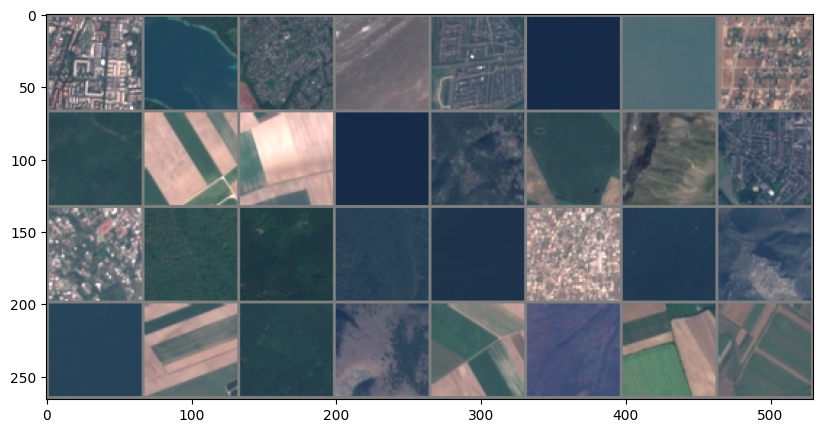

Residential SeaLake Residential HerbaceousVegetation Residential SeaLake SeaLake Residential Forest AnnualCrop AnnualCrop SeaLake HerbaceousVegetation AnnualCrop HerbaceousVegetation Residential Residential Forest Forest Forest SeaLake Residential SeaLake HerbaceousVegetation SeaLake AnnualCrop Forest HerbaceousVegetation AnnualCrop HerbaceousVegetation AnnualCrop AnnualCrop


In [5]:
def imshow(img):
    img = img / 2 + 0.5     # desnormalizar
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Visualizar un batch de entrenamiento
if 'train_loader' in locals():
    dataiter = iter(train_loader)
    images, labels = next(dataiter)

    # Mostrar imágenes
    plt.figure(figsize=(10, 5))
    imshow(torchvision.utils.make_grid(images))
    # Imprimir etiquetas
    print(' '.join(f'{classes[labels[j]]:5s}' for j in range(len(labels))))

## 2. Arquitectura CNN Base

Definimos una arquitectura CNN básica con capas convolucionales, pooling y capas totalmente conectadas.

In [6]:
class BaseCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(BaseCNN, self).__init__()
        # Input: 3 x 64 x 64
        self.features = nn.Sequential(
            # Bloque 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1), # 32 x 64 x 64
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),      # 32 x 32 x 32

            # Bloque 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 64 x 32 x 32
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),       # 64 x 16 x 16

            # Bloque 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # 128 x 16 x 16
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),        # 128 x 8 x 8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Instanciar modelo
num_classes = len(classes) if 'classes' in locals() else 5
model = BaseCNN(num_classes=num_classes).to(device)
print(model)

# Hiperparámetros
learning_rate = 0.001
num_epochs = 10
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

BaseCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=5, bias=True)
  )
)


In [7]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    train_loss_history = []
    train_acc_history = []
    val_loss_history = []
    val_acc_history = []

    for epoch in range(num_epochs):
        # Fase de Entrenamiento
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = correct / total
        train_loss_history.append(epoch_loss)
        train_acc_history.append(epoch_acc)

        # Fase de Validación
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader)
        val_acc = val_correct / val_total
        val_loss_history.append(val_loss)
        val_acc_history.append(val_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    return train_loss_history, train_acc_history, val_loss_history, val_acc_history

# Entrenar Modelo Base
if 'train_loader' in locals():
    print("Entrenando CNN Base...")
    base_train_loss, base_train_acc, base_val_loss, base_val_acc = train_model(
        model, train_loader, val_loader, criterion, optimizer, num_epochs=num_epochs
    )

Entrenando CNN Base...
Epoch [1/10], Train Loss: 0.5905, Train Acc: 0.7517, Val Loss: 0.3529, Val Acc: 0.8671
Epoch [2/10], Train Loss: 0.3121, Train Acc: 0.8871, Val Loss: 0.2692, Val Acc: 0.8987
Epoch [3/10], Train Loss: 0.2386, Train Acc: 0.9139, Val Loss: 0.1674, Val Acc: 0.9458
Epoch [4/10], Train Loss: 0.1831, Train Acc: 0.9327, Val Loss: 0.2076, Val Acc: 0.9204
Epoch [5/10], Train Loss: 0.1627, Train Acc: 0.9414, Val Loss: 0.2929, Val Acc: 0.8880
Epoch [6/10], Train Loss: 0.1327, Train Acc: 0.9534, Val Loss: 0.1596, Val Acc: 0.9476
Epoch [7/10], Train Loss: 0.1442, Train Acc: 0.9536, Val Loss: 0.1351, Val Acc: 0.9600
Epoch [8/10], Train Loss: 0.1081, Train Acc: 0.9607, Val Loss: 0.1346, Val Acc: 0.9551
Epoch [9/10], Train Loss: 0.0988, Train Acc: 0.9647, Val Loss: 0.1909, Val Acc: 0.9462
Epoch [10/10], Train Loss: 0.0775, Train Acc: 0.9750, Val Loss: 0.2573, Val Acc: 0.9409


## 3. Investigación sobre Dropout 

**¿Qué es Dropout?**
La técnica de abandono (Dropout), es una
 estrategia de regularización utilizada en
 redes neuronales para prevenir el
 sobreajuste al reducir la dependencia entre
 neuronas. Esta técnica implica "abandonar"
 aleatoriamente un conjunto de neuronas
 durante el entrenamiento, lo que significa
 que se excluyen temporalmente de la
 propagación hacia adelante y hacia atrás.

**¿Cómo ayuda a reducir el sobreajuste?**
La idea detrás del abandono es que, al forzar a la red a aprender con neuronas
 ausentes en diferentes momentos, se evita que las neuronas se vuelvan demasiado
 dependientes entre sí. Esto mejora la generalización del modelo, ya que las neuronas
 deben aprender a ser útiles incluso cuando otras están "apagadas". Además, el
 abandono actúa como una especie de ensamble de modelos, ya que cada iteración de
 entrenamiento utiliza un conjunto diferente de neuronas. 
El abandono se aplica típicamente en capas ocultas durante la fase de entrenamiento,
 y durante la inferencia (o evaluación), todas las neuronas se utilizan. Esto se hace para
 asegurar que el modelo se beneficie completamente de todas sus capacidades
 durante la predicción.


**Implementación:**
Añadiremos capas `nn.Dropout` después de las activaciones ReLU en las capas totalmente conectadas (o después de las convoluciones si se desea, pero es más común en FC). Usaremos una tasa de dropout de 0.5 (50% de probabilidad de apagado), que es un valor estándar efectivo.

In [8]:
class DropoutCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(DropoutCNN, self).__init__()
        # Input: 3 x 64 x 64
        self.features = nn.Sequential(
            # Bloque 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Bloque 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Bloque 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(p=0.5), # Dropout añadido
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Instanciar modelo con Dropout
dropout_model = DropoutCNN(num_classes=num_classes).to(device)
print(dropout_model)

# Optimizador para el nuevo modelo
optimizer_dropout = optim.Adam(dropout_model.parameters(), lr=learning_rate)

# Entrenar Modelo con Dropout
if 'train_loader' in locals():
    print("Entrenando CNN con Dropout...")
    drop_train_loss, drop_train_acc, drop_val_loss, drop_val_acc = train_model(
        dropout_model, train_loader, val_loader, criterion, optimizer_dropout, num_epochs=num_epochs
    )

DropoutCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=5, bias=True)
  )
)
Entrenando CNN con Dropout...
Epoch [1/10], Train Loss: 0.6130, Train Acc: 0.7437, Val Loss: 0.3305, Val Acc: 0.8627
Epoch [2/10], Train Loss: 0.3581, Train Acc: 0.8679, Val Loss:

## 4. Comparación y Análisis (Tarea 3)

Comparamos el desempeño de ambas arquitecturas utilizando el conjunto de prueba y visualizando las curvas de entrenamiento.

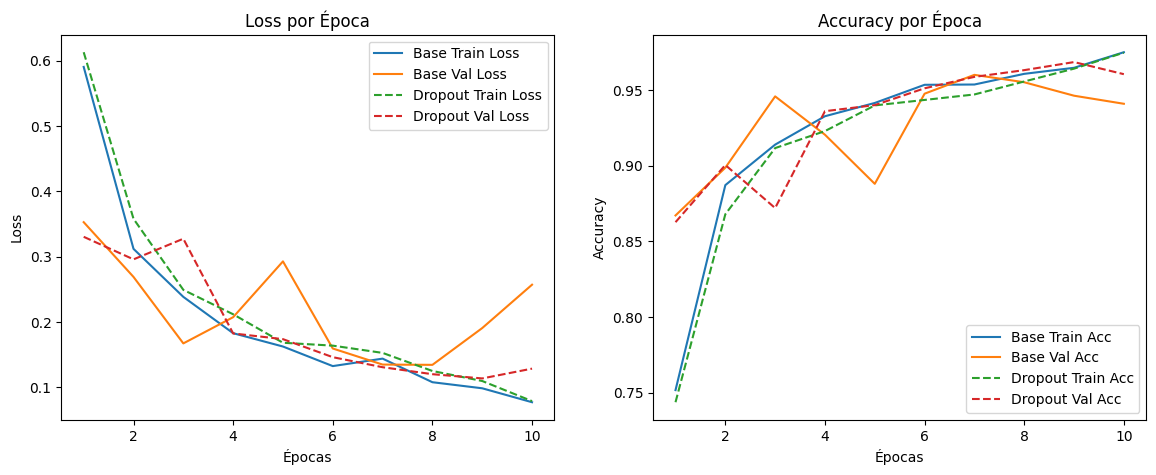

In [9]:
# Visualización de Curvas de Aprendizaje
epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(14, 5))

# Gráfico de Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, base_train_loss, label='Base Train Loss')
plt.plot(epochs_range, base_val_loss, label='Base Val Loss')
plt.plot(epochs_range, drop_train_loss, label='Dropout Train Loss', linestyle='--')
plt.plot(epochs_range, drop_val_loss, label='Dropout Val Loss', linestyle='--')
plt.title('Loss por Época')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

# Gráfico de Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, base_train_acc, label='Base Train Acc')
plt.plot(epochs_range, base_val_acc, label='Base Val Acc')
plt.plot(epochs_range, drop_train_acc, label='Dropout Train Acc', linestyle='--')
plt.plot(epochs_range, drop_val_acc, label='Dropout Val Acc', linestyle='--')
plt.title('Accuracy por Época')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [10]:
def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    return acc, f1

if 'test_loader' in locals():
    base_acc, base_f1 = evaluate_model(model, test_loader)
    drop_acc, drop_f1 = evaluate_model(dropout_model, test_loader)
    
    print(f"Resultados en Conjunto de Prueba:")
    print(f"Base CNN    - Accuracy: {base_acc:.4f}, F1-Score: {base_f1:.4f}")
    print(f"Dropout CNN - Accuracy: {drop_acc:.4f}, F1-Score: {drop_f1:.4f}")
    
    # Interpretación breve
    print("\nInterpretación:")
    if drop_acc > base_acc:
        print("El modelo con Dropout generalizó mejor en el conjunto de prueba.")
    else:
        print("El modelo Base tuvo un desempeño similar o mejor. Esto puede depender de la cantidad de épocas o la complejidad del dataset.")

Resultados en Conjunto de Prueba:
Base CNN    - Accuracy: 0.9409, F1-Score: 0.9406
Dropout CNN - Accuracy: 0.9587, F1-Score: 0.9590

Interpretación:
El modelo con Dropout generalizó mejor en el conjunto de prueba.


## 5. Justificación de Hiperparámetros y Uso de Datos

### 5.1 Justificación de Hiperparámetros

- **Número de capas (3 bloques convolucionales):**  
  Se emplean tres bloques Conv–ReLU–MaxPool. Esto permite que la red aprenda una jerarquía de características: en las primeras capas se detectan bordes y texturas simples, y en las capas más profundas se combinan para formar patrones más complejos. Para imágenes pequeñas de 64×64, esta profundidad es suficiente sin llegar a arquitecturas muy profundas como VGG-16 o ResNet, manteniendo el costo computacional razonable.  
  *Referencia:* Goodfellow et al., *Deep Learning*, cap. 6 (MIT Press, 2016).

- **Filtros por bloque (32, 64, 128):**  
  El número de filtros aumenta progresivamente (32→64→128) a medida que la resolución espacial se reduce por el pooling. Este patrón está inspirado en redes tipo VGG, donde se duplica el número de canales al bajar la resolución para representar patrones cada vez más complejos sin incrementar demasiado el costo computacional.  
  *Referencia:* Simonyan & Zisserman, “Very Deep Convolutional Networks for Large-Scale Image Recognition (VGG)”, ICLR 2015.

- **Tamaño de kernel (3×3 con padding 1):**  
  Los kernels 3×3 con padding 1 son el estándar de facto en CNNs modernas: capturan dependencias locales con pocos parámetros y, al apilar varias capas 3×3, se logra un campo receptivo efectivo grande equivalente a usar kernels más grandes, pero con menos pesos. El padding 1 mantiene el tamaño espacial tras la convolución, lo que simplifica el diseño de la red.  
  *Referencia:* Simonyan & Zisserman (VGG); Goodfellow et al., cap. 6.

- **Función de activación (ReLU):**  
  Se utiliza ReLU en todas las capas ocultas porque es simple, computacionalmente barata y reduce el problema del “gradiente que se desvanece” de activaciones sigmoides o tanh. Esto se traduce en entrenamientos más rápidos y estables en redes profundas.  
  *Referencia:* Goodfellow et al., cap. 6; documentación oficial de PyTorch (`torch.nn.ReLU`).

- **Optimizador (Adam):**  
  El entrenamiento usa el optimizador Adam (`torch.optim.Adam`), que combina Momentum y RMSProp para adaptar automáticamente la tasa de aprendizaje de cada parámetro a partir de los primeros momentos del gradiente. Adam es uno de los optimizadores más utilizados en práctica porque suele converger rápido y requiere poco ajuste fino inicial.  
  *Referencia:* Kingma & Ba, “Adam: A Method for Stochastic Optimization”, ICLR 2015.

- **Learning Rate (0.001):**  
  Se fija una tasa de aprendizaje \(\eta = 0.001\), que es el valor por defecto recomendado para Adam en la mayoría de librerías (Keras, PyTorch). Este valor proporciona un buen equilibrio entre rapidez de convergencia y estabilidad: tasas mucho mayores pueden provocar explosión de la pérdida, mientras que tasas muy pequeñas hacen el entrenamiento innecesariamente lento.  
  *Referencia:* Kingma & Ba (Adam); Goodfellow et al., cap. 8 (selección de tasa de aprendizaje).

- **Batch Size (32):**  
  Se elige un tamaño de lote de 32 ejemplos. Los mini-batches en el rango 16–64 son recomendados en muchos trabajos de deep learning porque ofrecen gradientes suficientemente estables sin exigir demasiada memoria. Batches muy pequeños introducen demasiado ruido en el gradiente y batches muy grandes pueden empeorar la generalización si no se ajusta el learning rate.  
  *Referencia:* Goodfellow et al., cap. 8 (mini-batch SGD); estudios empíricos sobre batch size en CNN.

- **Número de épocas (10):**  
  Entrenar durante 10 épocas permite que el modelo alcance una región de buena convergencia sin un tiempo de cómputo excesivo. En la práctica, el número óptimo de épocas se suele determinar observando la evolución de la pérdida y la accuracy de validación (o usando *early stopping*), pero para un dataset de tamaño medio como EuroSAT y una red moderada, 10 épocas es un valor típico en ejemplos docentes y benchmarks rápidos.  
  *Referencia:* Goodfellow et al., cap. 8 (criterios de parada); ejemplos de entrenamiento sobre EuroSAT.

- **Función de pérdida (CrossEntropyLoss):**  
  Se utiliza `nn.CrossEntropyLoss`, que combina softmax y entropía cruzada. Es la función estándar para problemas de clasificación multiclase, donde cada imagen pertenece exactamente a una de las clases, y está recomendada en la documentación de PyTorch para este tipo de tareas.  
  *Referencia:* Documentación oficial de PyTorch (`torch.nn.CrossEntropyLoss`).

- **Dropout (p = 0.5 en la capa densa):**  
  En el segundo modelo se aplica `Dropout(p=0.5)` después de la activación ReLU en la capa totalmente conectada de 512 neuronas. Dropout apaga aleatoriamente cada neurona con probabilidad \(p\) durante el entrenamiento, rompiendo coadaptaciones entre unidades y funcionando como una forma de regularización que mejora la capacidad de generalización. El valor \(p ≈ 0.5\) en capas densas es el recomendado en el trabajo original de Srivastava et al. y se ha convertido en un estándar. Además, tiene sentido aplicarlo en la capa densa porque es donde se concentra la mayor parte de los parámetros de la red.  
  *Referencia:* Srivastava et al., “Dropout: A Simple Way to Prevent Neural Networks from Overfitting”, JMLR 2014; Goodfellow et al., cap. 7 (regularización).

### 5.2 Uso de Datos y Métricas

- **Partición 70/15/15 (train/valid/test):**  
  El dataset se divide en 70 % entrenamiento, 15 % validación y 15 % prueba. Este esquema de 3 conjuntos es una recomendación común en guías de buenas prácticas:  
  - el conjunto de entrenamiento se usa para ajustar los parámetros del modelo,  
  - el de validación para seleccionar hiperparámetros (por ejemplo, decidir si dropout mejora la pérdida de validación o cuándo detener el entrenamiento),  
  - y el de prueba se reserva para la evaluación final, sin utilizarlo en decisiones de diseño para evitar un sesgo optimista.  
  *Referencia:* Lightly.ai, “Train Test Validation Split: Best Practices & Examples”; documentación y guías de Google Developers sobre división de datasets.

- **Métricas (Accuracy y F1 ponderado):**  
  Se emplean dos métricas sobre el conjunto de prueba:  
  - **Accuracy**, que mide el porcentaje de imágenes correctamente clasificadas sobre el total y es la métrica global más directa en clasificación.  
  - **F1-score ponderado**, que combina precisión y *recall* para cada clase y luego promedia ponderando por el número de ejemplos de cada clase. Esta métrica es útil cuando puede existir cierto desbalance entre clases, ya que asegura que todas las categorías contribuyan al valor global.  
  *Referencia:* Documentación de scikit-learn (`accuracy_score`, `f1_score`).

---

### 5.3 Bibliografía

- Helber, P., Bischke, B., Dengel, A., & Borth, D. (2019). **EuroSAT: A Novel Dataset and Deep Learning Benchmark for Land Use and Land Cover Classification**. *IEEE JSTARS*.  
  Disponible en: https://arxiv.org/abs/1709.00029   

- Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. (2014). **Dropout: A Simple Way to Prevent Neural Networks from Overfitting**. *Journal of Machine Learning Research, 15*.  
  Disponible en: https://jmlr.org/papers/v15/srivastava14a.html   

- Kingma, D. P., & Ba, J. (2015). **Adam: A Method for Stochastic Optimization**. *ICLR 2015*.  
  Disponible en: https://arxiv.org/abs/1412.6980 

- Goodfellow, I., Bengio, Y., & Courville, A. (2016). **Deep Learning**. MIT Press.  
  Versión online (gratuita): https://www.deeplearningbook.org/ 

- Simonyan, K., & Zisserman, A. (2015). **Very Deep Convolutional Networks for Large-Scale Image Recognition** (VGG). *ICLR 2015*.  
  Disponible en: https://arxiv.org/abs/1409.1556  

- Lightly.ai Blog. **Train Test Validation Split: Best Practices & Examples**.  
  Disponible en: https://www.lightly.ai/blog/train-test-validation-split  

- Google Developers. **Dividing the Original Dataset** (Machine Learning Crash Course).  
  Disponible en: https://developers.google.com/machine-learning/crash-course/overfitting/dividing-datasets  

- PyTorch. **`torch.nn.CrossEntropyLoss` – documentación oficial**.  
  Disponible en: https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html  

- scikit-learn. **`accuracy_score` – documentación oficial**.  
  Disponible en: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html  
  (Versión en español no oficial: https://qu4nt.github.io/sklearn-doc-es/modules/generated/sklearn.metrics.accuracy_score.html)  

- scikit-learn. **`f1_score` – documentación oficial**.  
  Disponible en: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html

- DataCamp. **`Dropout` – Regularización del abandono mediante PyTorch: Guía práctica**.  
  Disponible en: https://www.datacamp.com/es/tutorial/dropout-regularization-using-pytorch-guide